# Lab 03 — Edge Detection Techniques and Their Impact on Classification Performance

Builds on Lab 01 (pretrained-model comparison) and Lab 02 (filter effects).
Uses the same dataset, class list and 80/20 split as Lab 02
(`nodoubttome/skin-cancer9-classesisic`, classes: melanoma, nevus,
pigmented benign keratosis, basal cell carcinoma).

**Sections**
1. Setup
2. Dataset preparation
3. Task 1 — Comparative edge detection (Sobel, Prewitt, Laplacian, LoG, Canny)
4. Task 2 — Effect of noise on edge detection
5. Task 3 — Canny parameter analysis
6. Task 4 — Dataset versions (Raw / Filtered / Edge) for classification
7. Task 4/5 — Train & evaluate classifiers on all three versions
8. Task 5 — Cross-lab performance table
9. Task 6 — Confusion matrices & bar chart
10. Discussion questions
11. Viva questions
12. Package results


## 1. Setup

In [1]:
!pip -q install opencv-python-headless scikit-learn scikit-image kagglehub

import os, glob, time, json, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. The CNN part of this notebook will be very slow -- "
          "in Colab go to Runtime > Change runtime type > GPU.")

os.makedirs("results", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)


Device: cuda


In [2]:
CONFIG = {
    "img_size": 224,
    "n_representative_per_class": 1,   # for Task 1/2/3 figures, >=3 classes required by the brief
    "canny_configs": [                  # Task 3 -- (name, low, high, ksize)
        ("Canny-1", 30, 100, 3),
        ("Canny-2", 50, 150, 3),
        ("Canny-3", 100, 200, 3),
        ("Canny-4", 50, 150, 5),
    ],
    "sp_amount": 0.03,        # salt-and-pepper fraction
    "gauss_noise_sigma": 25,  # gaussian noise std-dev (0-255 scale)
    "median_ksize": 5,
    "gaussian_ksize": 5,
    "warmup_epochs": 1,
    "finetune_epochs": 4,
    "batch_size": 32,
    "lr_warmup": 1e-3,
    "lr_finetune": 1e-4,
}
print(CONFIG)


{'img_size': 224, 'n_representative_per_class': 1, 'canny_configs': [('Canny-1', 30, 100, 3), ('Canny-2', 50, 150, 3), ('Canny-3', 100, 200, 3), ('Canny-4', 50, 150, 5)], 'sp_amount': 0.03, 'gauss_noise_sigma': 25, 'median_ksize': 5, 'gaussian_ksize': 5, 'warmup_epochs': 1, 'finetune_epochs': 4, 'batch_size': 32, 'lr_warmup': 0.001, 'lr_finetune': 0.0001}


## 2. Dataset preparation

Same defensive auto-detection and class list as Lab 02, so the split, images and classes are
identical across Labs 01-03 as the brief requires.

In [3]:
import kagglehub

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
print("Path to dataset files:", path)

train_candidates = sorted(glob.glob(f"{path}/**/Train", recursive=True))
test_candidates  = sorted(glob.glob(f"{path}/**/Test",  recursive=True))
train_dir = train_candidates[0] if train_candidates else None  # <-- SET MANUALLY IF WRONG
test_dir  = test_candidates[0]  if test_candidates  else None  # <-- SET MANUALLY IF WRONG
assert train_dir and test_dir, "Could not auto-detect Train/Test folders -- set manually."

SELECTED_CLASSES = sorted([
    "melanoma",
    "nevus",
    "pigmented benign keratosis",
    "basal cell carcinoma",
])
SHORT_NAMES = {"basal cell carcinoma": "BCC", "melanoma": "MEL",
               "nevus": "NV", "pigmented benign keratosis": "PBK"}

for cname in SELECTED_CLASSES:
    for split_dir in [train_dir, test_dir]:
        assert os.path.isdir(os.path.join(split_dir, cname)), f"Missing {split_dir}/{cname}"

print("Classes:", SELECTED_CLASSES)
print("Train dir:", train_dir)
print("Test dir :", test_dir)


100%|██████████| 786M/786M [00:08<00:00, 96.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1
Classes: ['basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis']
Train dir: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Train
Test dir : /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration/Test


In [4]:
def build_file_list(split_dir, classes):
    items = []
    for c in classes:
        cdir = os.path.join(split_dir, c)
        for fname in os.listdir(cdir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                items.append((os.path.join(cdir, fname), c))
    return items

train_files_all = build_file_list(train_dir, SELECTED_CLASSES)
test_files       = build_file_list(test_dir, SELECTED_CLASSES)

# same 80/20 train/val split logic (seeded) as Lab 02, so results stay comparable
g = torch.Generator().manual_seed(SEED)
idx = torch.randperm(len(train_files_all), generator=g).tolist()
n_val = int(0.2 * len(train_files_all))
val_idx, tr_idx = idx[:n_val], idx[n_val:]
train_files = [train_files_all[i] for i in tr_idx]
val_files   = [train_files_all[i] for i in val_idx]

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")
for c in SELECTED_CLASSES:
    n = sum(1 for _, lbl in train_files_all if lbl == c) + sum(1 for _, lbl in test_files if lbl == c)
    print(f"  {c:30s} ({SHORT_NAMES[c]}): {n} images total")


Train: 1307 | Val: 326 | Test: 64
  basal cell carcinoma           (BCC): 392 images total
  melanoma                       (MEL): 454 images total
  nevus                          (NV): 373 images total
  pigmented benign keratosis     (PBK): 478 images total


In [5]:
# One representative image per class, for the Task 1/2/3 figures (>=3 classes required)
random.seed(SEED)
representative = {}
for c in SELECTED_CLASSES:
    candidates = [p for p, lbl in train_files_all if lbl == c]
    representative[c] = random.choice(candidates)

def load_gray(path, size=CONFIG["img_size"]):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img, gray

rep_images = {c: load_gray(p) for c, p in representative.items()}
print("Representative images selected for:", list(rep_images.keys()))


Representative images selected for: ['basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis']


## 3. Task 1 — Comparative Edge Detection

First-order (Sobel Gx/Gy/magnitude, Prewitt), second-order (Laplacian, LoG), and the
multi-stage Canny detector.

In [6]:
def sobel_gx(gray):
    return cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

def sobel_gy(gray):
    return cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

def sobel_magnitude(gray):
    gx, gy = sobel_gx(gray), sobel_gy(gray)
    mag = np.sqrt(gx**2 + gy**2)
    return np.uint8(255 * mag / (mag.max() + 1e-8))

def prewitt(gray):
    kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
    gx = cv2.filter2D(gray.astype(np.float32), -1, kx)
    gy = cv2.filter2D(gray.astype(np.float32), -1, ky)
    mag = np.sqrt(gx**2 + gy**2)
    return np.uint8(255 * mag / (mag.max() + 1e-8))

def laplacian(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return np.uint8(255 * np.abs(lap) / (np.abs(lap).max() + 1e-8))

def log_edge(gray, ksize=9, sigma=1.4):
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
    return np.uint8(255 * np.abs(lap) / (np.abs(lap).max() + 1e-8))

def canny(gray, low=50, high=150, ksize=3):
    return cv2.Canny(gray, low, high, apertureSize=ksize if ksize in (3, 5, 7) else 3, L2gradient=True)

EDGE_METHODS = {
    "Sobel (Gx)": sobel_gx,
    "Sobel (Gy)": sobel_gy,
    "Sobel (magnitude)": sobel_magnitude,
    "Prewitt": prewitt,
    "Laplacian": laplacian,
    "LoG": log_edge,
    "Canny": canny,
}
print("Edge detectors ready:", list(EDGE_METHODS.keys()))


Edge detectors ready: ['Sobel (Gx)', 'Sobel (Gy)', 'Sobel (magnitude)', 'Prewitt', 'Laplacian', 'LoG', 'Canny']


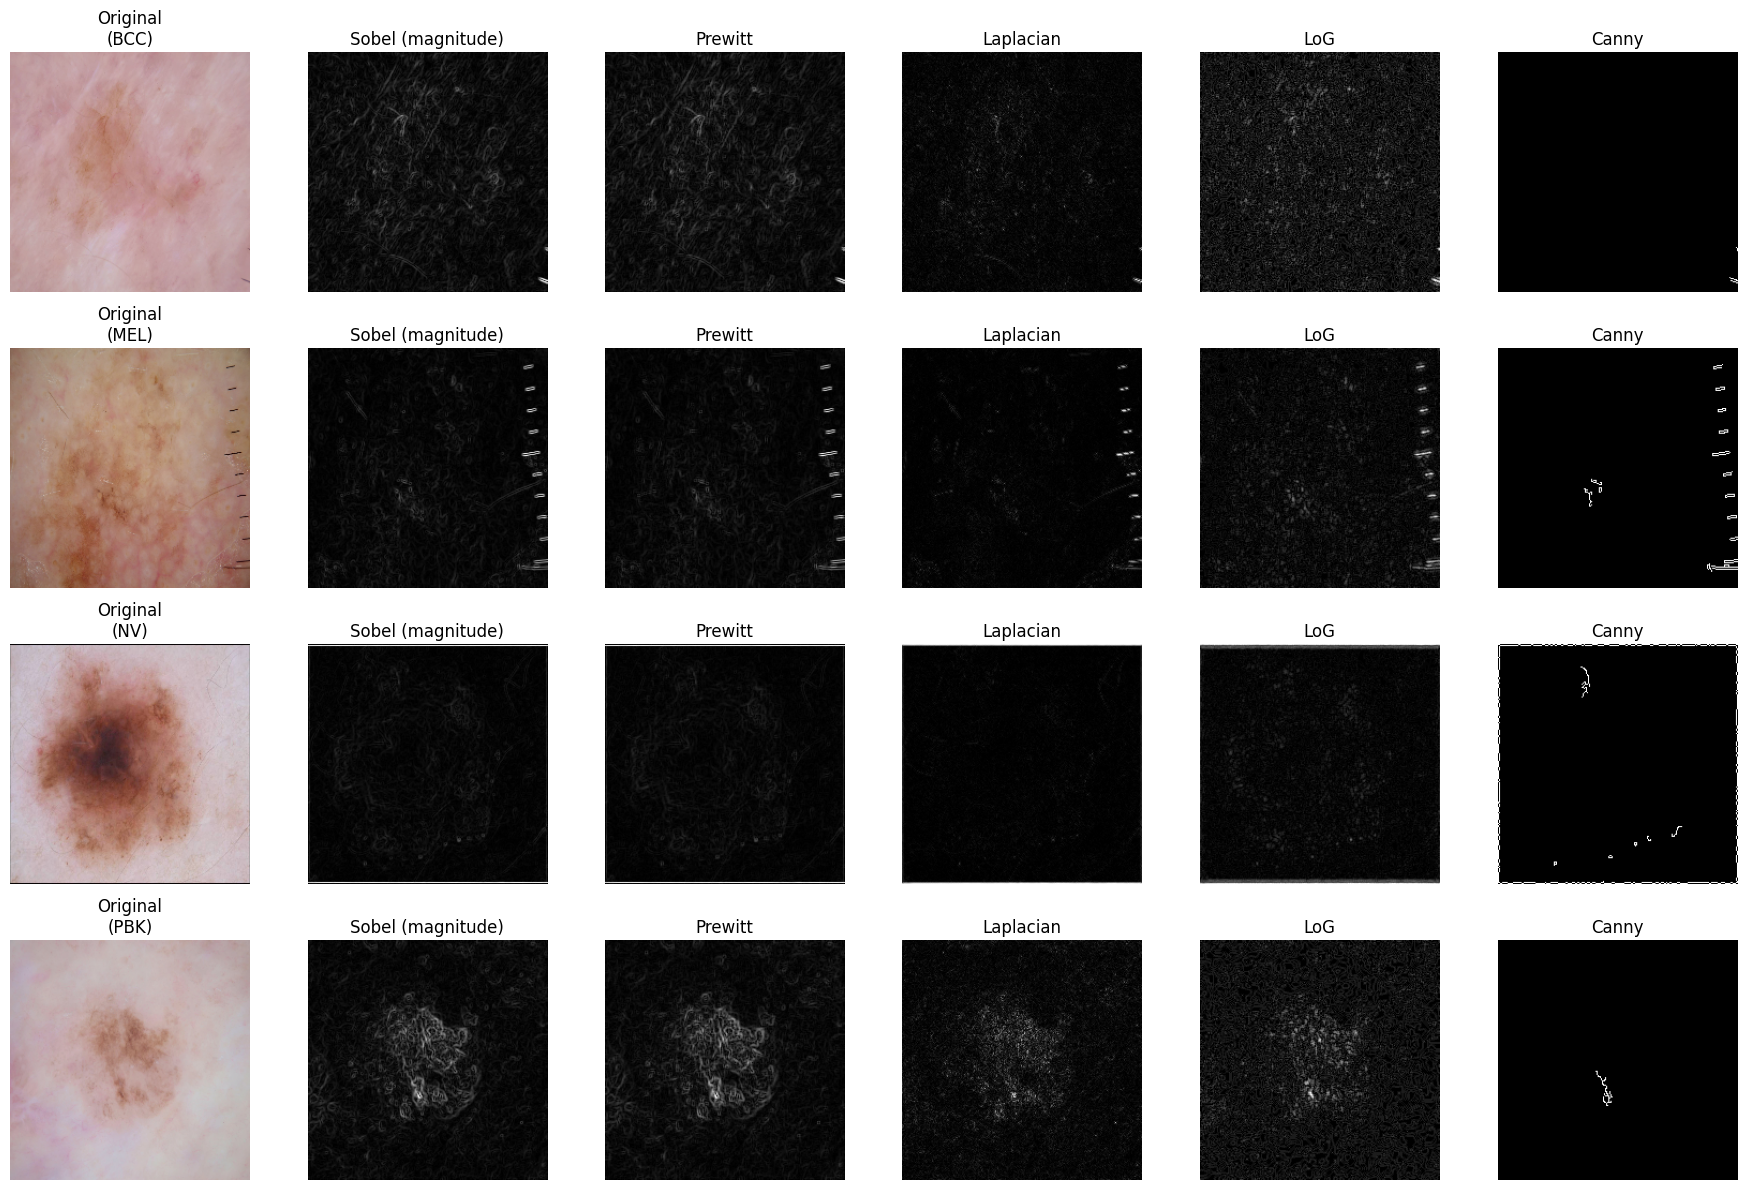

In [7]:
# Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny, >=3 classes
fig_methods = ["Sobel (magnitude)", "Prewitt", "Laplacian", "LoG", "Canny"]
classes_to_show = SELECTED_CLASSES  # all 4 -- satisfies the "at least three" requirement

fig, axes = plt.subplots(len(classes_to_show), len(fig_methods) + 1,
                          figsize=(3 * (len(fig_methods) + 1), 3 * len(classes_to_show)))
for r, c in enumerate(classes_to_show):
    rgb, gray = rep_images[c]
    axes[r, 0].imshow(rgb); axes[r, 0].set_title(f"Original\n({SHORT_NAMES[c]})"); axes[r, 0].axis("off")
    for col, name in enumerate(fig_methods, start=1):
        out = EDGE_METHODS[name](gray)
        cmap = "gray" if out.ndim == 2 else None
        axes[r, col].imshow(out, cmap="gray"); axes[r, col].set_title(name); axes[r, col].axis("off")
plt.tight_layout()
plt.savefig("results/figures/task1_edge_comparison.png", dpi=150)
plt.show()


## 4. Task 2 — Effect of Noise on Edge Detection

Gaussian noise and salt-and-pepper noise, each followed by no preprocessing / Gaussian
filtering / Median filtering, then edge detection -- exactly the rows of **Table 1**.

In [8]:
def add_gaussian_noise(gray, sigma=CONFIG["gauss_noise_sigma"]):
    noise = np.random.normal(0, sigma, gray.shape)
    return np.clip(gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(gray, amount=CONFIG["sp_amount"]):
    out = gray.copy()
    n_pixels = gray.size
    n_salt = int(amount * n_pixels / 2)
    n_pepper = int(amount * n_pixels / 2)
    ys = np.random.randint(0, gray.shape[0], n_salt); xs = np.random.randint(0, gray.shape[1], n_salt)
    out[ys, xs] = 255
    ys = np.random.randint(0, gray.shape[0], n_pepper); xs = np.random.randint(0, gray.shape[1], n_pepper)
    out[ys, xs] = 0
    return out

def gaussian_filter(gray, k=CONFIG["gaussian_ksize"]):
    return cv2.GaussianBlur(gray, (k, k), 0)

def median_filter(gray, k=CONFIG["median_ksize"]):
    return cv2.medianBlur(gray, k)

def edge_quality_metrics(edge_img, reference_edge_img=None):
    """Automated proxies for the qualitative columns of Table 1/2:
    - edge_density: fraction of pixels flagged as edge (thresholded)
    - n_components: connected-component count -> rough continuity/false-edge proxy
      (very high count relative to a clean reference suggests broken/false edges)
    """
    binary = (edge_img > 30).astype(np.uint8)
    density = float(binary.mean())
    n_components, _ = cv2.connectedComponents(binary)
    return {"edge_density": round(density, 4), "n_components": int(n_components - 1)}


In [9]:
# Use one representative image (first class) as the running example for Task 2 and its figure
demo_class = SELECTED_CLASSES[0]
_, demo_gray = rep_images[demo_class]

rows = [
    ("Sobel", "Original", "None", "None"),
    ("Sobel", "Noisy", "Gaussian", "None"),
    ("Sobel", "Noisy", "Salt & Pepper", "None"),
    ("Sobel", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Sobel", "Noisy", "Salt & Pepper", "Median Filter"),
    ("Prewitt", "Original", "None", "None"),
    ("Laplacian", "Original", "None", "None"),
    ("LoG", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Canny", "Original", "None", "Built-in smoothing"),
    ("Canny", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Canny", "Noisy", "Salt & Pepper", "Median Filter"),
]
detector_fn = {"Sobel": sobel_magnitude, "Prewitt": prewitt, "Laplacian": laplacian,
               "LoG": log_edge, "Canny": canny}

def make_input(input_type, noise_type, prep):
    img = demo_gray.copy()
    if input_type == "Noisy":
        img = add_gaussian_noise(img) if noise_type == "Gaussian" else add_salt_pepper_noise(img)
    if prep == "Gaussian Filter":
        img = gaussian_filter(img)
    elif prep == "Median Filter":
        img = median_filter(img)
    return img

table1_rows = []
panel_imgs, panel_titles = [], []
for detector, input_type, noise_type, prep in rows:
    inp = make_input(input_type, noise_type, prep)
    edge = detector_fn[detector](inp)
    m = edge_quality_metrics(edge)
    table1_rows.append({
        "Edge Detector": detector, "Input Image": input_type, "Noise Type": noise_type,
        "Preprocessing": prep, "Edge Density": m["edge_density"], "Connected Components": m["n_components"],
        "Observations": "<-- fill in after inspecting the figure below (continuity / sharpness / false edges)",
    })
    panel_imgs.append(edge)
    panel_titles.append(f"{detector}\n{input_type}/{noise_type}\n{prep}")

table1 = pd.DataFrame(table1_rows)
table1.to_csv("results/table1_noise_effects.csv", index=False)
table1


,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Density,Connected Components,Observations
0,Sobel,Original,None,None,0.0956,577,<-- fill in after inspecting the figure below ...
1,Sobel,Noisy,Gaussian,None,0.8612,4,<-- fill in after inspecting the figure below ...
2,Sobel,Noisy,Salt & Pepper,None,0.2076,679,<-- fill in after inspecting the figure below ...
3,Sobel,Noisy,Gaussian,Gaussian Filter,0.7770,17,<-- fill in after inspecting the figure below ...
4,Sobel,Noisy,Salt & Pepper,Median Filter,0.4906,176,<-- fill in after inspecting the figure below ...
5,Prewitt,Original,None,None,0.1025,607,<-- fill in after inspecting the figure below ...
6,Laplacian,Original,None,None,0.0197,518,<-- fill in after inspecting the figure below ...
7,LoG,Noisy,Gaussian,Gaussian Filter,0.6894,28,<-- fill in after inspecting the figure below ...
8,Canny,Original,None,Built-in smoothing,0.0004,2,<-- fill in after inspecting the figure below ...
9,Canny,Noisy,Gaussian,Gaussian Filter,0.0000,0,<-- fill in after inspecting the figure below ...


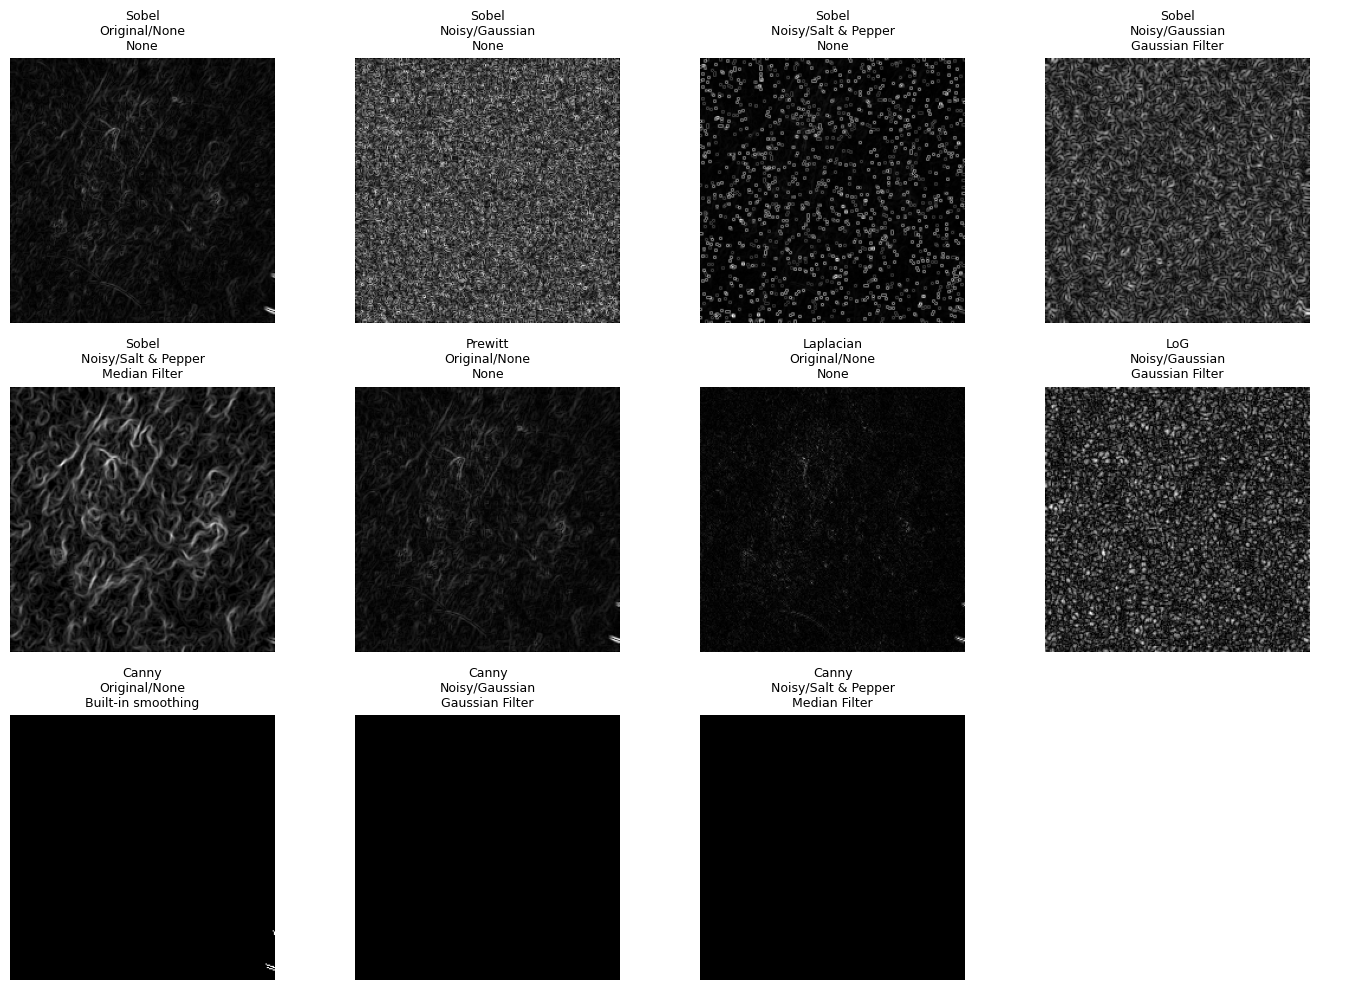

Higher 'Connected Components' relative to the clean baseline row = more broken/false edges from noise; a drop back down after filtering = smoothing is restoring continuity. Use these numbers plus the figure above to write the Observations column.


In [10]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, img, title in zip(axes.ravel(), panel_imgs, panel_titles):
    ax.imshow(img, cmap="gray"); ax.set_title(title, fontsize=9); ax.axis("off")
for ax in axes.ravel()[len(panel_imgs):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/figures/task2_noise_effects.png", dpi=150)
plt.show()
print("Higher 'Connected Components' relative to the clean baseline row = more broken/false edges "
      "from noise; a drop back down after filtering = smoothing is restoring continuity. "
      "Use these numbers plus the figure above to write the Observations column.")


## 5. Task 3 — Canny Parameter Analysis

In [11]:
table2_rows = []
canny_panel_imgs, canny_panel_titles = [], []
for name, low, high, ksize in CONFIG["canny_configs"]:
    edge = canny(demo_gray, low, high, ksize)
    m = edge_quality_metrics(edge)
    n_edges = int((edge > 0).sum())
    table2_rows.append({
        "Configuration": name, "Low Threshold": low, "High Threshold": high, "Kernel Size": f"{ksize}x{ksize}",
        "Edge Density": m["edge_density"], "Number of Detected Edges (px)": n_edges,
        "Observation": "<-- fill in after inspecting the figure below",
    })
    canny_panel_imgs.append(edge)
    canny_panel_titles.append(f"{name}\nlow={low} high={high} k={ksize}")

table2 = pd.DataFrame(table2_rows)
table2.to_csv("results/table2_canny_params.csv", index=False)
table2


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Density,Number of Detected Edges (px),Observation
0,Canny-1,30,100,3x3,0.0015,74,<-- fill in after inspecting the figure below
1,Canny-2,50,150,3x3,0.0004,20,<-- fill in after inspecting the figure below
2,Canny-3,100,200,3x3,0.0003,15,<-- fill in after inspecting the figure below
3,Canny-4,50,150,5x5,0.2936,14732,<-- fill in after inspecting the figure below


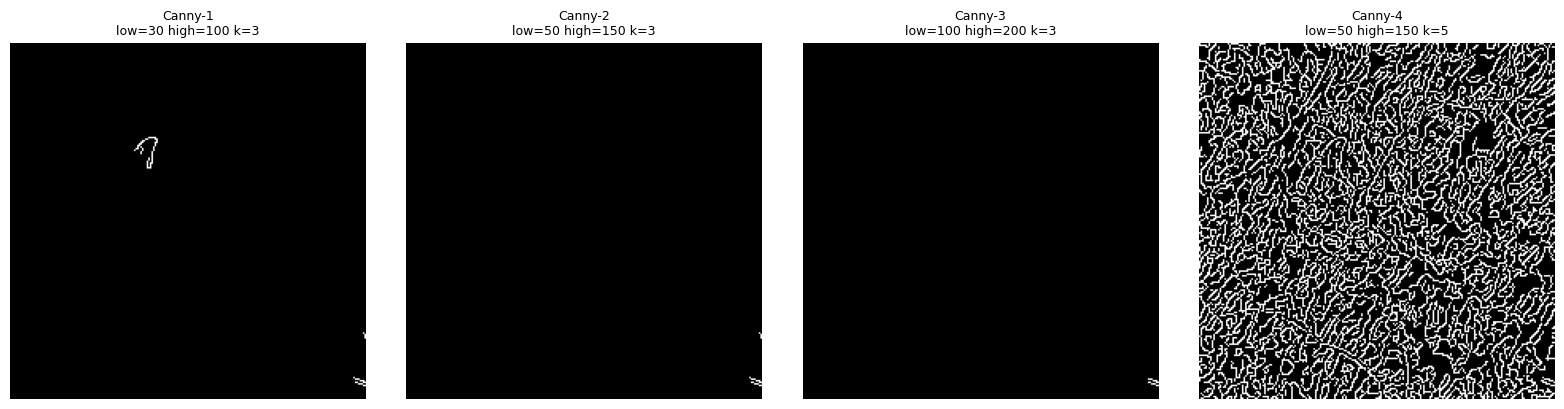

Auto-selected best Canny config (edit TARGET_DENSITY above to change the rule): {'low': 30, 'high': 100, 'ksize': 3}


In [12]:
fig, axes = plt.subplots(1, len(canny_panel_imgs), figsize=(4 * len(canny_panel_imgs), 4))
for ax, img, title in zip(axes, canny_panel_imgs, canny_panel_titles):
    ax.imshow(img, cmap="gray"); ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout()
plt.savefig("results/figures/task3_canny_params.png", dpi=150)
plt.show()

# Automatic pick: the config whose edge density is closest to a reference "moderate" density
# (too low = missed edges, too high = noisy). 8% is a reasonable moderate target for a 224x224
# lesion crop -- adjust TARGET_DENSITY and re-run if your images look over/under-segmented.
TARGET_DENSITY = 0.08
table2["_dist"] = (table2["Edge Density"] - TARGET_DENSITY).abs()
best_row = table2.loc[table2["_dist"].idxmin()]
BEST_CANNY = {"low": int(best_row["Low Threshold"]), "high": int(best_row["High Threshold"]),
              "ksize": int(best_row["Kernel Size"].split("x")[0])}
table2 = table2.drop(columns="_dist")
print("Auto-selected best Canny config (edit TARGET_DENSITY above to change the rule):", BEST_CANNY)


## 6. Task 4 — Three Dataset Versions (Raw / Filtered / Edge)

- **Set A (Raw):** unmodified images, same as Lab 01.
- **Set B (Filtered):** best filter identified in Lab 02, auto-loaded from Lab 02's
  `filter_summary.csv` when available (falls back to Gaussian filtering with a warning
  if that file isn't found, since it's the generically safest default among Lab 02's options).
- **Set C (Edge):** the `BEST_CANNY` configuration selected in Task 3 above.

All three use the identical train/val/test split built in Section 2.

In [13]:
BEST_FILTER_NAME = "gaussian"  # fallback default
lab2_summary_paths = glob.glob("/content/**/filter_summary.csv", recursive=True) + \
                     glob.glob("/mnt/**/filter_summary.csv", recursive=True)
if lab2_summary_paths:
    lab2_summary = pd.read_csv(lab2_summary_paths[0])
    BEST_FILTER_NAME = lab2_summary.iloc[0, 0]
    print(f"Loaded best filter from Lab 02 results: {BEST_FILTER_NAME}")
else:
    print(f"Could not find Lab 02's filter_summary.csv in this environment -- "
          f"defaulting to '{BEST_FILTER_NAME}'. Upload/mount that file and re-run this cell "
          f"to use the actual Lab 02 result instead.")

def apply_best_filter(rgb):
    if BEST_FILTER_NAME.lower().startswith("gauss"):
        return cv2.GaussianBlur(rgb, (5, 5), 0)
    elif BEST_FILTER_NAME.lower().startswith("median"):
        return cv2.medianBlur(rgb, 5)
    elif BEST_FILTER_NAME.lower().startswith("average") or BEST_FILTER_NAME.lower().startswith("mean"):
        return cv2.blur(rgb, (5, 5))
    elif BEST_FILTER_NAME.lower().startswith("sharp"):
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(rgb, -1, kernel)
    elif BEST_FILTER_NAME.lower().startswith("sobel"):
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        return cv2.cvtColor(sobel_magnitude(gray), cv2.COLOR_GRAY2RGB)
    return rgb

def apply_best_edge(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    edge = canny(gray, BEST_CANNY["low"], BEST_CANNY["high"], BEST_CANNY["ksize"])
    return cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)  # 3-channel so it can feed pretrained backbones


Could not find Lab 02's filter_summary.csv in this environment -- defaulting to 'gaussian'. Upload/mount that file and re-run this cell to use the actual Lab 02 result instead.


In [20]:
from PIL import Image

class LesionDataset(Dataset):
    def __init__(self, files, classes, representation, train=False):
        self.files = files
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.representation = representation  # "raw" | "filtered" | "edge"
        self.size = CONFIG["img_size"]
        aug = [T.RandomHorizontalFlip(), T.RandomRotation(10)] if train else []
        self.post = T.Compose(aug + [
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        p, label = self.files[i]
        img = cv2.imread(p, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))
        if self.representation == "filtered":
            img = apply_best_filter(img)
        elif self.representation == "edge":
            img = apply_best_edge(img)
        img = Image.fromarray(img) # Convert numpy array to PIL Image
        img = self.post(img)
        return img, self.class_to_idx[label]

def make_loaders(representation):
    tr = LesionDataset(train_files, SELECTED_CLASSES, representation, train=True)
    va = LesionDataset(val_files, SELECTED_CLASSES, representation, train=False)
    te = LesionDataset(test_files, SELECTED_CLASSES, representation, train=False)
    dl = lambda ds, shuffle: DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=shuffle, num_workers=2)
    return dl(tr, True), dl(va, False), dl(te, False)

print("Dataset classes ready for representations: raw, filtered, edge")

Dataset classes ready for representations: raw, filtered, edge


## 7. Train & Evaluate Classifiers

**Classical classifiers (SVM, Random Forest, KNN):** trained on deep features extracted from a
frozen pretrained ResNet18 -- identical feature extractor across all three representations, so
the comparison is fair (feature extraction is what changes with the input, not the extractor).

**CNN Model 1 / CNN Model 2:** the top-2 backbones from Lab 01's Table 1 (`ResNet50`, `AlexNet`
per Lab 02's config comment) fine-tuned end-to-end per representation, with the same
warmup->fine-tune schedule used in Labs 01-02.

In [21]:
def extract_features(loader, backbone):
    feats, labels = [], []
    backbone.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            f = backbone(x).squeeze(-1).squeeze(-1).cpu().numpy()
            feats.append(f); labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

def build_feature_extractor():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Identity()
    return m.to(DEVICE)

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}


In [22]:
def build_cnn(name, n_classes):
    if name == "ResNet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
    elif name == "AlexNet":
        m = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, n_classes)
    else:
        raise ValueError(name)
    return m.to(DEVICE)

def train_cnn(model, train_loader, val_loader, warmup_epochs, finetune_epochs, lr_warmup, lr_finetune):
    criterion = nn.CrossEntropyLoss()
    # phase 1: warm up the new head only
    for p in model.parameters():
        p.requires_grad = False
    head = model.fc if hasattr(model, "fc") else model.classifier[6]
    for p in head.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(head.parameters(), lr=lr_warmup)
    for _ in range(warmup_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss = criterion(model(x), y); loss.backward(); opt.step()
    # phase 2: fine-tune everything
    for p in model.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=lr_finetune)
    for _ in range(finetune_epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss = criterion(model(x), y); loss.backward(); opt.step()
    return model

def evaluate_cnn(model, loader):
    model.eval()
    preds, labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x).argmax(1).cpu().numpy()
            preds.append(out); labels.append(y.numpy())
    infer_ms = 1000 * (time.time() - t0) / len(loader.dataset)
    return np.concatenate(preds), np.concatenate(labels), infer_ms


In [23]:
REPRESENTATIONS = ["raw", "filtered", "edge"]
CLASSICAL = {
    "SVM": lambda: SVC(kernel="rbf", C=10, gamma="scale"),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, random_state=SEED),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=7),
}
CNN_MODELS = ["ResNet50", "AlexNet"]   # top-2 backbones carried over from Lab 01/02

RESULTS_PATH = "results/results_lab3.json"
all_results = json.load(open(RESULTS_PATH)) if os.path.exists(RESULTS_PATH) else {}

def save_results():
    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

feature_extractor = build_feature_extractor()

for rep in REPRESENTATIONS:
    train_loader, val_loader, test_loader = make_loaders(rep)

    # ---- classical classifiers on frozen deep features ----
    key_feat = f"__features__{rep}"
    if key_feat not in all_results:
        t0 = time.time()
        Xtr, ytr = extract_features(train_loader, feature_extractor)
        feat_time = time.time() - t0
        Xte, yte = extract_features(test_loader, feature_extractor)
        np.savez(f"results/feats_{rep}.npz", Xtr=Xtr, ytr=ytr, Xte=Xte, yte=yte)
        all_results[key_feat] = {"feat_time_s": feat_time}
        save_results()
    else:
        d = np.load(f"results/feats_{rep}.npz")
        Xtr, ytr, Xte, yte = d["Xtr"], d["ytr"], d["Xte"], d["yte"]

    for clf_name, clf_fn in CLASSICAL.items():
        run_key = f"{clf_name}|{rep}"
        if run_key in all_results:
            continue
        clf = clf_fn()
        t0 = time.time(); clf.fit(Xtr, ytr); train_s = time.time() - t0
        t0 = time.time(); preds = clf.predict(Xte); infer_ms = 1000 * (time.time() - t0) / len(yte)
        m = compute_metrics(yte, preds)
        all_results[run_key] = {**m, "train_time_s": train_s, "infer_time_ms": infer_ms,
                                 "y_true": yte.tolist(), "y_pred": preds.tolist()}
        save_results()
        print(run_key, {k: round(v, 4) for k, v in m.items()})

    # ---- CNN models, fine-tuned end-to-end ----
    for cnn_name in CNN_MODELS:
        run_key = f"{cnn_name}|{rep}"
        if run_key in all_results:
            continue
        model = build_cnn(cnn_name, len(SELECTED_CLASSES))
        t0 = time.time()
        model = train_cnn(model, train_loader, val_loader, CONFIG["warmup_epochs"],
                           CONFIG["finetune_epochs"], CONFIG["lr_warmup"], CONFIG["lr_finetune"])
        train_s = time.time() - t0
        preds, labels, infer_ms = evaluate_cnn(model, test_loader)
        m = compute_metrics(labels, preds)
        all_results[run_key] = {**m, "train_time_s": train_s, "infer_time_ms": infer_ms,
                                 "y_true": labels.tolist(), "y_pred": preds.tolist()}
        save_results()
        print(run_key, {k: round(v, 4) for k, v in m.items()})

print("All 15 runs (5 classifiers x 3 representations) complete or already cached.")


SVM|raw {'accuracy': 0.5469, 'precision': 0.6002, 'recall': 0.5469, 'f1': 0.539}
Random Forest|raw {'accuracy': 0.5, 'precision': 0.577, 'recall': 0.5, 'f1': 0.4754}
KNN|raw {'accuracy': 0.5469, 'precision': 0.5418, 'recall': 0.5469, 'f1': 0.5408}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


ResNet50|raw {'accuracy': 0.6562, 'precision': 0.7646, 'recall': 0.6562, 'f1': 0.5927}
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 127MB/s]


AlexNet|raw {'accuracy': 0.6719, 'precision': 0.7072, 'recall': 0.6719, 'f1': 0.634}
SVM|filtered {'accuracy': 0.4375, 'precision': 0.5024, 'recall': 0.4375, 'f1': 0.4359}
Random Forest|filtered {'accuracy': 0.4844, 'precision': 0.5864, 'recall': 0.4844, 'f1': 0.4985}
KNN|filtered {'accuracy': 0.4375, 'precision': 0.4612, 'recall': 0.4375, 'f1': 0.4377}
ResNet50|filtered {'accuracy': 0.7031, 'precision': 0.8058, 'recall': 0.7031, 'f1': 0.6355}
AlexNet|filtered {'accuracy': 0.6562, 'precision': 0.7561, 'recall': 0.6562, 'f1': 0.6208}
SVM|edge {'accuracy': 0.2812, 'precision': 0.2864, 'recall': 0.2812, 'f1': 0.2775}
Random Forest|edge {'accuracy': 0.4219, 'precision': 0.4268, 'recall': 0.4219, 'f1': 0.4104}
KNN|edge {'accuracy': 0.3438, 'precision': 0.3417, 'recall': 0.3438, 'f1': 0.3388}
ResNet50|edge {'accuracy': 0.4062, 'precision': 0.393, 'recall': 0.4062, 'f1': 0.3839}
AlexNet|edge {'accuracy': 0.4375, 'precision': 0.4046, 'recall': 0.4375, 'f1': 0.3934}
All 15 runs (5 classifiers x

## 8. Task 5 — Table 3: Cross-Lab Classification Performance Comparison

In [24]:
model_order = list(CLASSICAL.keys()) + CNN_MODELS
table3_rows = []
for model_name in model_order:
    row = {"Model / Classifier": model_name}
    for rep, label in zip(REPRESENTATIONS, ["Accuracy Raw (Lab 1)", "Accuracy Filtered (Lab 2)", "Accuracy Edge (Lab 3)"]):
        r = all_results.get(f"{model_name}|{rep}", {})
        row[label] = round(r.get("accuracy", float("nan")), 4)
    # precision/recall/F1/times reported for the Edge representation (Lab 3's own contribution)
    r_edge = all_results.get(f"{model_name}|edge", {})
    row["Precision"] = round(r_edge.get("precision", float("nan")), 4)
    row["Recall"] = round(r_edge.get("recall", float("nan")), 4)
    row["F1-Score"] = round(r_edge.get("f1", float("nan")), 4)
    row["Training Time (s)"] = round(r_edge.get("train_time_s", float("nan")), 2)
    row["Inference Time (ms)"] = round(r_edge.get("infer_time_ms", float("nan")), 3)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows)
table3.to_csv("results/table3_crosslab_comparison.csv", index=False)
print(table3.to_markdown(index=False))
table3


| Model / Classifier   |   Accuracy Raw (Lab 1) |   Accuracy Filtered (Lab 2) |   Accuracy Edge (Lab 3) |   Precision |   Recall |   F1-Score |   Training Time (s) |   Inference Time (ms) |
|:---------------------|-----------------------:|----------------------------:|------------------------:|------------:|---------:|-----------:|--------------------:|----------------------:|
| SVM                  |                 0.5469 |                      0.4375 |                  0.2812 |      0.2864 |   0.2812 |     0.2775 |                0.5  |                 0.509 |
| Random Forest        |                 0.5    |                      0.4844 |                  0.4219 |      0.4268 |   0.4219 |     0.4104 |                9.57 |                 0.345 |
| KNN                  |                 0.5469 |                      0.4375 |                  0.3438 |      0.3417 |   0.3438 |     0.3388 |                0    |                 0.112 |
| ResNet50             |                 0.6562 | 

,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,0.5469,0.4375,0.2812,0.2864,0.2812,0.2775,0.50,0.509
1,Random Forest,0.5000,0.4844,0.4219,0.4268,0.4219,0.4104,9.57,0.345
2,KNN,0.5469,0.4375,0.3438,0.3417,0.3438,0.3388,0.00,0.112
3,ResNet50,0.6562,0.7031,0.4062,0.3930,0.4062,0.3839,74.05,10.323
4,AlexNet,0.6719,0.6562,0.4375,0.4046,0.4375,0.3934,61.60,7.408


## 9. Task 6 — Confusion Matrices & Bar Chart (best model)

Best-performing model on the Edge representation: AlexNet


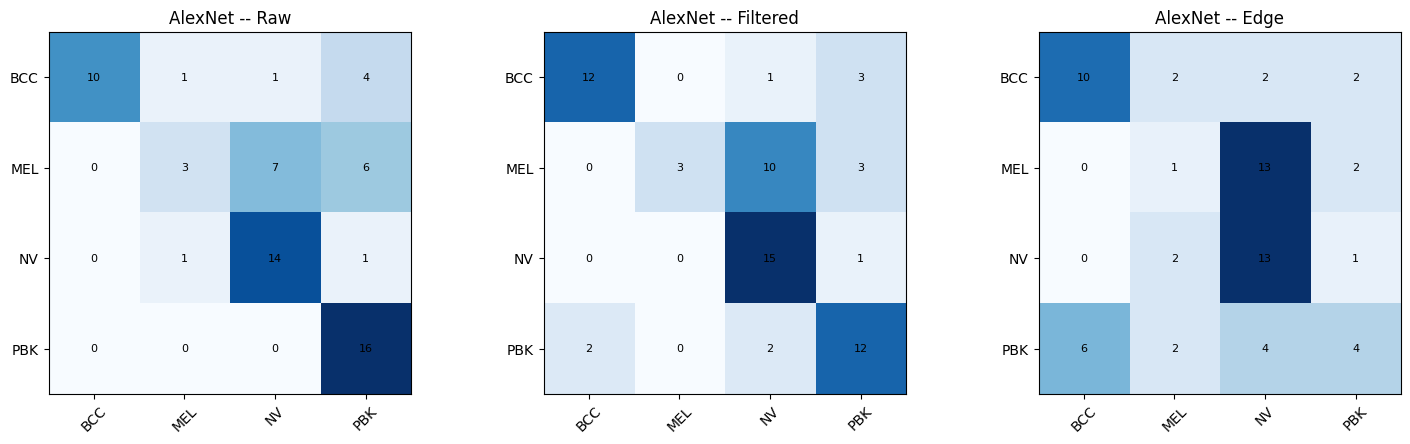

In [25]:
best_model = table3.loc[table3["Accuracy Edge (Lab 3)"].idxmax(), "Model / Classifier"]
print("Best-performing model on the Edge representation:", best_model)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, rep, title in zip(axes, REPRESENTATIONS, ["Raw", "Filtered", "Edge"]):
    r = all_results[f"{best_model}|{rep}"]
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{best_model} -- {title}")
    ax.set_xticks(range(len(SELECTED_CLASSES))); ax.set_xticklabels([SHORT_NAMES[c] for c in SELECTED_CLASSES], rotation=45)
    ax.set_yticks(range(len(SELECTED_CLASSES))); ax.set_yticklabels([SHORT_NAMES[c] for c in SELECTED_CLASSES])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("results/figures/task6_confusion_matrices.png", dpi=150)
plt.show()


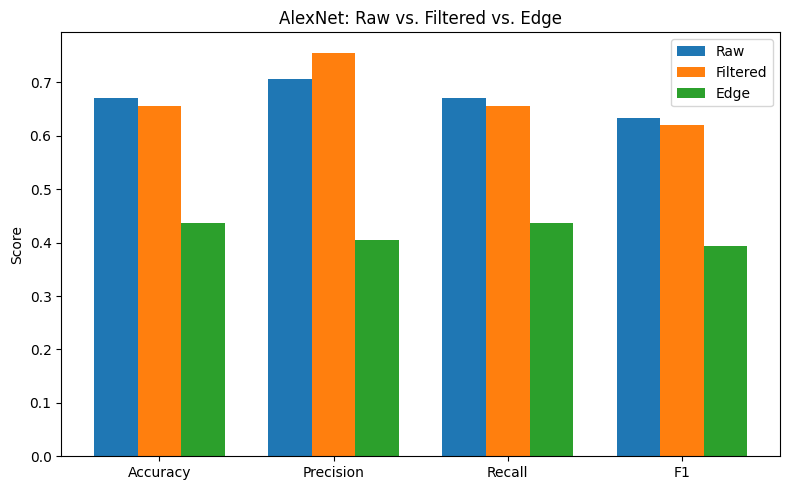

For AlexNet, edge-only input reduces accuracy vs. raw (0.4375 vs 0.6719). Use this for Task 6's discussion and Question 4 below.


In [26]:
metrics_names = ["accuracy", "precision", "recall", "f1"]
bar_data = {rep: [all_results[f"{best_model}|{rep}"][m] for m in metrics_names] for rep in REPRESENTATIONS}

x = np.arange(len(metrics_names)); width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, rep in enumerate(REPRESENTATIONS):
    ax.bar(x + (i - 1) * width, bar_data[rep], width, label=rep.capitalize())
ax.set_xticks(x); ax.set_xticklabels([m.capitalize() for m in metrics_names])
ax.set_ylabel("Score"); ax.set_title(f"{best_model}: Raw vs. Filtered vs. Edge")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/task6_bar_chart.png", dpi=150)
plt.show()

edge_acc = all_results[f"{best_model}|edge"]["accuracy"]
raw_acc = all_results[f"{best_model}|raw"]["accuracy"]
verdict = "improves" if edge_acc > raw_acc else "reduces"
print(f"For {best_model}, edge-only input {verdict} accuracy vs. raw "
      f"({edge_acc:.4f} vs {raw_acc:.4f}). Use this for Task 6's discussion and Question 4 below.")


## 10. Discussion Questions

**Q1 -- Edge Detection and Noise.** Rank the detectors in `table1` by how much their edge
density/connected-component count shifts between the "Original" row and the noisy rows for the
same detector; the one with the largest shift is the most noise-sensitive. Run the cell below to
get the automatic ranking, then explain *why* in your report (e.g. Laplacian/LoG differentiate
twice, so they amplify high-frequency noise more than Sobel/Prewitt's single differentiation).

**Q2 -- Effect of Filtering.** Compare the "Noisy + Gaussian Filter" and "Noisy + Median Filter"
rows in `table1` against their unfiltered "Noisy" counterparts -- did edge density/continuity move
back toward the clean baseline? Median filtering is expected to help salt-and-pepper noise more
than Gaussian filtering does, since it doesn't average in the extreme outlier pixel values.

**Q3 -- Canny Parameters.** See `table2`: lower thresholds keep more (and weaker/noisier) edges;
raising both thresholds keeps only strong edges, reducing edge count and noise but risking broken
outlines. Reference the actual "Number of Detected Edges" values from your run.

**Q4 -- Edge Maps and Classification.** Answered programmatically above (`verdict`) -- explain in
your report that edge maps discard color/texture, which usually costs accuracy unless texture is
uninformative or heavily confounded by artifacts (rulers, hair, lighting) in the raw image.

**Q5 -- Information Loss.** Texture (e.g. lesion surface pattern), color (a strong diagnostic cue
in dermoscopy), and absolute/relative intensity are all discarded -- only boundary shape survives.

**Q6 -- Classical vs. Deep Features.** A CNN learns task-optimal edge-like filters jointly with
everything downstream, can combine multiple edge orientations/scales, and isn't locked into one
fixed operator -- versus a hand-picked detector+threshold that must generalize to every image.

**Q7 -- Best Representation.** Pull the three accuracy columns from `table3` for your best model
and state which representation actually won for *your* run -- don't assume raw or edge without
checking the numbers.

In [27]:
noise_shift = []
baseline = {d: table1[(table1["Edge Detector"] == d) & (table1["Input Image"] == "Original")]["Edge Density"].mean()
            for d in table1["Edge Detector"].unique()}
for d in table1["Edge Detector"].unique():
    noisy_rows = table1[(table1["Edge Detector"] == d) & (table1["Input Image"] == "Noisy") & (table1["Preprocessing"] == "None")]
    if len(noisy_rows):
        shift = (noisy_rows["Edge Density"] - baseline.get(d, np.nan)).abs().mean()
        noise_shift.append({"Detector": d, "Mean |density shift| vs clean baseline": round(shift, 4)})
pd.DataFrame(noise_shift).sort_values("Mean |density shift| vs clean baseline", ascending=False)


,Detector,Mean |density shift| vs clean baseline
0,Sobel,0.4388


## 11. Viva Questions

1. **What is an edge in an image?** A location where pixel intensity changes sharply -- a large
   image gradient, usually corresponding to an object boundary.
2. **First-order vs. second-order edge detection?** First-order (Sobel, Prewitt) finds edges as
   *peaks* in the first derivative; second-order (Laplacian, LoG) finds them as *zero-crossings*
   of the second derivative.
3. **Sobel Gx vs. Gy?** Gx approximates the horizontal derivative and responds to vertical edges;
   Gy approximates the vertical derivative and responds to horizontal edges.
4. **Why is Laplacian more noise-sensitive?** It's a second derivative, and differentiation
   amplifies high-frequency content -- noise is high-frequency, so it gets amplified twice.
5. **Purpose of Gaussian smoothing before edge detection?** Suppresses high-frequency noise before
   differentiating, so the derivative isn't dominated by noise-driven spikes (this is exactly why
   LoG blurs before its Laplacian, and why Canny's first internal step is a Gaussian blur).
6. **Main advantage of Canny?** It's a full pipeline (smoothing -> gradient -> non-maximum
   suppression -> double threshold + hysteresis) that produces thin, connected, well-localized
   edges rather than the thick/noisy response of a single-kernel operator.
7. **Canny's low/high thresholds?** Gradient magnitudes above `high` are certain edges; below `low`
   are discarded; magnitudes in between are kept only if connected to a certain edge (hysteresis).
8. **Gaussian vs. Salt-and-Pepper noise?** Gaussian noise perturbs every pixel by a small random
   amount drawn from a normal distribution; salt-and-pepper noise randomly sets a fraction of
   pixels to pure black or pure white, leaving the rest untouched.
9. **Why is Median filtering good for salt-and-pepper noise?** It replaces each pixel with the
   median of its neighborhood, so an extreme outlier (0 or 255) is simply discarded rather than
   averaged in, unlike a mean/Gaussian filter which lets the outlier drag the result toward it.
10. **Why can edge detection reduce classification performance?** It discards color, texture and
    intensity information the classifier could have used, keeping only boundary shape.
11. **Can a CNN learn edge features automatically?** Yes -- early convolutional layers in a
    trained CNN commonly learn Sobel/Gabor-like oriented edge filters on their own from data.
12. **Why might raw images outperform edge-only images?** Because color/texture cues (e.g.
    lesion pigmentation pattern) can carry diagnostic signal that a boundary-only representation
    throws away, especially when the classes aren't well separated by shape alone.


## 12. Package Results for Submission

In [28]:
import shutil
shutil.make_archive("/content/lab03_results", "zip", "results")
print("Packaged -> /content/lab03_results.zip")
try:
    from google.colab import files
    files.download("/content/lab03_results.zip")
except Exception as e:
    print("(download only works inside Colab)", e)


Packaged -> /content/lab03_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes / Limitations

- This notebook has not been executed in this environment -- all tables, figures and the
  auto-selected `BEST_CANNY` / best model are computed live when you run it, not hardcoded.
- `BEST_FILTER_NAME` is auto-loaded from Lab 02's `filter_summary.csv` if that file is reachable
  in this Colab session; otherwise it falls back to Gaussian filtering and prints a warning --
  double-check the printed value matches your actual Lab 02 result before submitting.
- `CNN_MODELS = ["ResNet50", "AlexNet"]` follows the "top-2 from Lab 1" comment already in the
  Lab 02 notebook; swap these if your own Lab 1 ranking differs.
- `TARGET_DENSITY` in Task 3's auto-selection is a heuristic, not a rule from the brief -- inspect
  the Task 3 figure yourself and override `BEST_CANNY` manually if a different configuration
  looks better for your images.
